DSA3361 - Inferential Data Analytics

### Tutorial 5 - Multiple Linear Regression

- Concept Review

    - Model & Data

    - Estimate of β 

    - Testing β = 0

    - Range estimate of β 

    - (Range) estimate of ŷ

Access code: **<span style="color:red">ci4y</span>**

In [8]:
import pandas as pd
df= pd.read_excel("../data/football.xlsx")
print(df)

               Team   y    x1    x2    x3    x4  x5    x6    x7    x8    x9
0        Washington  10  2113  1985  38.9  64.7   4   868  59.7  2205  1917
1         Minnesota  11  2003  2855  38.8  61.3   3   615  55.0  2096  1575
2       New England  11  2957  1737  40.1  60.0  14   914  65.6  1847  2175
3           Oakland  13  2285  2905  41.6  45.3  -4   957  61.4  1903  2476
4        Pittsburgh  10  2971  1666  39.2  53.8  15   836  66.1  1457  1866
5         Baltimore  11  2309  2927  39.7  74.1   8   786  61.0  1848  2339
6       Los Angeles  10  2528  2341  38.1  65.4  12   754  66.1  1564  2092
7            Dallas  11  2147  2737  37.0  78.3  -1   761  58.0  1821  1909
8           Atlanta   4  1689  1414  42.1  47.6  -3   714  57.0  2577  2001
9           Buffalo   2  2566  1838  42.3  54.2  -1   797  58.9  2476  2254
10          Chicago   7  2363  1480  37.3  48.0  19   984  67.5  1984  2217
11       Cincinnati  10  2109  2191  39.5  51.9   6   700  57.2  1917  1758
12        Cl

In [9]:
import statsmodels.api as sm
xs = df[["x2","x7","x8"]]
X = sm.add_constant(xs)
y = df[["y"]]
model = sm.OLS(y, X).fit()
model.params

const   -1.808372
x2       0.003598
x7       0.193960
x8      -0.004815
dtype: float64

In [10]:
model.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
const,-1.8084,7.901,-0.229,0.821,-18.115,14.498
x2,0.0036,0.001,5.177,0.000,0.002,0.005
x7,0.1940,0.088,2.198,0.038,0.012,0.376
x8,-0.0048,0.001,-3.771,0.001,-0.007,-0.002


In [11]:
x_new = pd.DataFrame({
    "const": [1],
    "x2": [2300],
    "x7": [56.0],
    "x8": [2100]
})

# Define x_new first
pred = model.get_prediction(x_new)
pred.summary_frame(alpha=0.05)

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,7.216424,0.378033,6.436203,7.996645,3.609523,10.823324


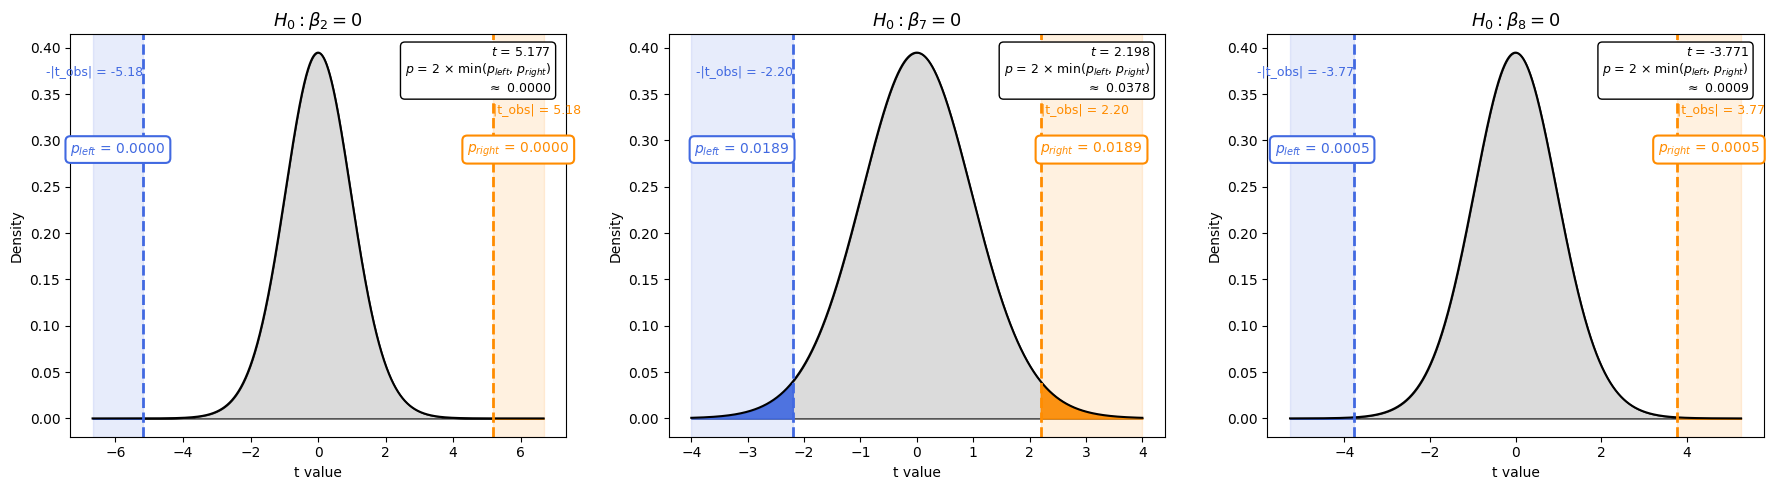

In [12]:
# If you want to visualize t-test

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import t

# ---------------------------
# Fit the regression model
# ---------------------------
df = pd.read_excel("../data/football.xlsx")

xs = df[["x2", "x7", "x8"]]
X = sm.add_constant(xs)
y = df["y"]

model = sm.OLS(y, X).fit()


# ---------------------------
# Plot function for one coefficient's t-test
# ---------------------------
def plot_regression_t_test(model, var_name, ax):

    # Observed t-statistic
    t_obs = model.tvalues[var_name]
    abs_t = abs(t_obs)

    # Degrees of freedom for residuals
    df_resid = int(model.df_resid)

    # Two tail probabilities
    p_left = t.cdf(-abs_t, df=df_resid)
    p_right = 1 - t.cdf(abs_t, df=df_resid)
    p_value = min(2 * min(p_left, p_right), 1)

    # x-grid for the theoretical t distribution under H0
    x_lim = max(4, abs_t + 1.5)
    x = np.linspace(-x_lim, x_lim, 2000)
    y_pdf = t.pdf(x, df=df_resid)

    # Main distribution
    ax.fill_between(
        x, 0, y_pdf,
        color="lightgray",
        edgecolor="black",
        linewidth=1.0,
        alpha=0.8,
        label=f"t distribution under $H_0$ (df = {df_resid})"
    )

    # Shade the two extreme regions
    ax.axvspan(
        x.min(),
        -abs_t,
        color="royalblue",
        alpha=0.12
    )

    ax.axvspan(
        abs_t,
        x.max(),
        color="darkorange",
        alpha=0.12
    )

    # Overlay tails
    left_mask = x <= -abs_t
    right_mask = x >= abs_t

    ax.fill_between(
        x[left_mask], 0, y_pdf[left_mask],
        color="royalblue",
        alpha=0.9,
        label="Left tail"
    )

    ax.fill_between(
        x[right_mask], 0, y_pdf[right_mask],
        color="darkorange",
        alpha=0.9,
        label="Right tail"
    )

    # Outline of t density
    ax.plot(x, y_pdf, color="black", linewidth=1.5)

    # Mark the two cutoffs
    ax.axvline(
        -abs_t,
        color="royalblue",
        linestyle="--",
        linewidth=2
    )

    ax.axvline(
        abs_t,
        color="darkorange",
        linestyle="--",
        linewidth=2
    )

    ymax = ax.get_ylim()[1]

    # Cutoff labels
    ax.text(
        -abs_t,
        ymax * 0.92,
        f"-|t_obs| = {-abs_t:.2f}",
        color="royalblue",
        ha="right",
        va="top",
        fontsize=9
    )

    ax.text(
        abs_t,
        ymax * 0.82,
        f"|t_obs| = {abs_t:.2f}",
        color="darkorange",
        ha="left",
        va="top",
        fontsize=9
    )

    # Tail probability boxes
    x_left = (x.min() - abs_t) / 2
    x_right = (abs_t + x.max()) / 2

    ax.text(
        x_left,
        ymax * 0.70,
        f"$p_{{left}}$ = {p_left:.4f}",
        color="royalblue",
        ha="center",
        va="center",
        fontsize=10,
        bbox=dict(
            boxstyle="round,pad=0.35",
            facecolor="white",
            edgecolor="royalblue",
            linewidth=1.5
        )
    )

    ax.text(
        x_right,
        ymax * 0.70,
        f"$p_{{right}}$ = {p_right:.4f}",
        color="darkorange",
        ha="center",
        va="center",
        fontsize=10,
        bbox=dict(
            boxstyle="round,pad=0.35",
            facecolor="white",
            edgecolor="darkorange",
            linewidth=1.5
        )
    )

    # Final two-tailed p-value box
    ax.text(
        0.97,
        0.97,
        f"$t$ = {t_obs:.3f}\n"
        f"$p$ = 2 × min($p_{{left}}$, $p_{{right}}$)\n"
        f"$\\approx$ {p_value:.4f}",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=9,
        bbox=dict(
            boxstyle="round,pad=0.35",
            facecolor="white",
            edgecolor="black"
        )
    )

    ax.set_title(
        f"$H_0: \\beta_{{{var_name[1:]}}}=0$",
        fontsize=13
    )

    ax.set_xlabel("t value", fontsize=10)
    ax.set_ylabel("Density", fontsize=10)


# ---------------------------
# Draw three figures horizontally
# ---------------------------
fig, axes = plt.subplots(
    1, 3,
    figsize=(18, 5)
)

for ax, var in zip(axes, ["x2", "x7", "x8"]):
    plot_regression_t_test(model, var, ax)

plt.tight_layout()
plt.show()

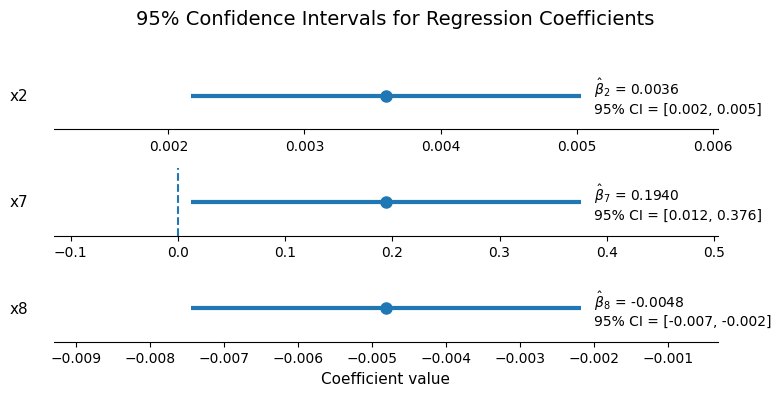

In [13]:
# If you want to visualize CI of β
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

# ---------------------------
# Fit the regression model
# ---------------------------
# df = pd.read_excel("football.xlsx")

xs = df[["x2", "x7", "x8"]]
X = sm.add_constant(xs)
y = df["y"]

model = sm.OLS(y, X).fit()

# ---------------------------
# Extract coefficients and 95% CIs
# ---------------------------
vars_to_plot = ["x2", "x7", "x8"]

coef = model.params[vars_to_plot]
ci = model.conf_int().loc[vars_to_plot]
lower = ci[0]
upper = ci[1]

# Map x2 -> beta_2, etc.
beta_labels = {
    "x2": r"$\hat{\beta}_2$",
    "x7": r"$\hat{\beta}_7$",
    "x8": r"$\hat{\beta}_8$"
}

# ---------------------------
# Create 3-row plot with different x-scales
# ---------------------------
fig, axes = plt.subplots(3, 1, figsize=(8,4))

for ax, var in zip(axes, vars_to_plot):
    beta_hat = coef[var]
    lo = lower[var]
    hi = upper[var]
    beta_label = beta_labels[var]

    # CI line
    ax.hlines(
        y=0,
        xmin=lo,
        xmax=hi,
        linewidth=3
    )

    # Point estimate
    ax.plot(
        beta_hat,
        0,
        marker="o",
        markersize=8
    )

    # Reference line at 0
    ax.axvline(
        0,
        linestyle="--",
        linewidth=1.5
    )

    # Set axis limits with padding
    width = hi - lo
    pad = 0.35 * width if width > 0 else 0.1
    ax.set_xlim(lo - pad, hi + pad)

    # Clean y-axis
    ax.set_yticks([])
    ax.set_ylabel(var, rotation=0, labelpad=25, fontsize=11, va="center")

    # Annotation on the right
    ax.text(
        hi + 0.02 * (ax.get_xlim()[1] - ax.get_xlim()[0]),
        0,
        f"{beta_label} = {beta_hat:.4f}\n95% CI = [{lo:.3f}, {hi:.3f}]",
        va="center",
        fontsize=10
    )

    # Remove unnecessary spines
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)

axes[-1].set_xlabel("Coefficient value", fontsize=11)

fig.suptitle("95% Confidence Intervals for Regression Coefficients", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

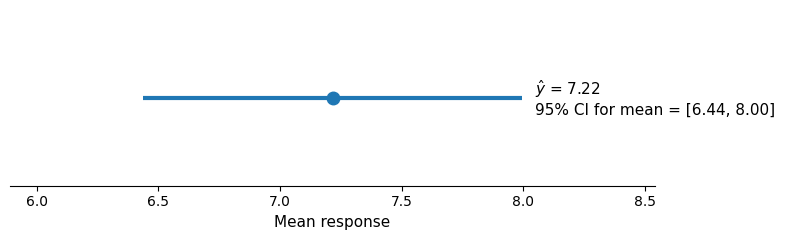

In [14]:
# If you want to visualize CI of ŷ

import matplotlib.pyplot as plt

# Prediction
x_new = pd.DataFrame({
    "const": [1],
    "x2": [2300],
    "x7": [56.0],
    "x8": [2100]
})

pred = model.get_prediction(x_new)
pred_summary = pred.summary_frame(alpha=0.05)

# Extract predicted mean and its 95% CI
y_hat = pred_summary["mean"].iloc[0]
lo = pred_summary["mean_ci_lower"].iloc[0]
hi = pred_summary["mean_ci_upper"].iloc[0]

# ---------------------------
# Plot
# ---------------------------
fig, ax = plt.subplots(figsize=(8, 2.5))

# 95% confidence interval
ax.hlines(
    y=0,
    xmin=lo,
    xmax=hi,
    linewidth=3
)

# Predicted mean
ax.plot(
    y_hat,
    0,
    marker="o",
    markersize=9
)

# Axis range with padding
width = hi - lo
pad = 0.35 * width
ax.set_xlim(lo - pad, hi + pad)

# Remove y-axis
ax.set_yticks([])

# Annotation
ax.text(
    hi + 0.02 * (ax.get_xlim()[1] - ax.get_xlim()[0]),
    0,
    f"$\\hat{{y}}$ = {y_hat:.2f}\n"
    f"95% CI for mean = [{lo:.2f}, {hi:.2f}]",
    va="center",
    fontsize=11
)

# Clean appearance
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.set_xlabel("Mean response", fontsize=11)

plt.tight_layout()
plt.show()